In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from scipy.stats import boxcox

In [2]:
drivers_4 = pd.read_csv("../data/clean/drivers_4_clean.csv")
drivers_14 = pd.read_csv("../data/clean/drivers_14_clean.csv")
drivers_19 = pd.read_csv("../data/clean/drivers_19_clean.csv")

In [3]:
drivers_4.corr()

,Unnamed: 0,AIR_INTAKE_TEMP,AMBIENT_AIR_TEMP,ENGINE_COOLANT_TEMP,ENGINE_LOAD,EQUIV_RATIO,MAF,SPEED,THROTTLE_POS,FUEL_LEVEL,INTAKE_MANIFOLD_PRESSURE,ENGINE_RPM
Unnamed: 0,1.000000,-0.730489,0.894506,0.546064,0.307807,-0.350745,0.486011,0.506646,0.467751,-0.884031,0.376315,0.629217
AIR_INTAKE_TEMP,-0.730489,1.000000,-0.672794,-0.199829,-0.425706,0.434142,-0.598693,-0.693662,-0.585728,0.595743,-0.430731,-0.739487
AMBIENT_AIR_TEMP,0.894506,-0.672794,1.000000,0.637222,0.253362,-0.312931,0.449881,0.418064,0.420893,-0.898051,0.313931,0.589589
ENGINE_COOLANT_TEMP,0.546064,-0.199829,0.637222,1.000000,0.104262,-0.066596,0.172810,0.067384,0.140160,-0.508596,0.155687,0.236143
ENGINE_LOAD,0.307807,-0.425706,0.253362,0.104262,1.000000,-0.534199,0.789719,0.484161,0.781635,-0.175083,0.512488,0.443187
EQUIV_RATIO,-0.350745,0.434142,-0.312931,-0.066596,-0.534199,1.000000,-0.686291,-0.547740,-0.712416,0.239981,-0.453352,-0.584754
MAF,0.486011,-0.598693,0.449881,0.172810,0.789719,-0.686291,1.000000,0.747076,0.933258,-0.305983,0.541992,0.752015
SPEED,0.506646,-0.693662,0.418064,0.067384,0.484161,-0.547740,0.747076,1.000000,0.698757,-0.230110,0.459419,0.849281
THROTTLE_POS,0.467751,-0.585728,0.420893,0.140160,0.781635,-0.712416,0.933258,0.698757,1.000000,-0.303335,0.546531,0.677598
FUEL_LEVEL,-0.884031,0.595743,-0.898051,-0.508596,-0.175083,0.239981,-0.305983,-0.230110,-0.303335,1.000000,-0.291542,-0.406260


In [4]:
# AMBIENT_AIR - FUEL_LEVEL
#Engine Load - MAF, THROTTLE_POS
#MAF - SPEED, THROTTLE POS
#SPEED - ENGINE_RPM
# Features - ENGINE_COOLANT_TEMP, AMBIENT_AIR_TEMP, ENGINE_LOAD, MAF, THROTTLE_POS, SPEED, ENGINE_RPM, FUEL_LEVEL

<AxesSubplot:>

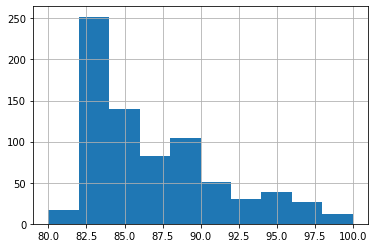

In [51]:
drivers_4["ENGINE_COOLANT_TEMP"].hist()

<AxesSubplot:>

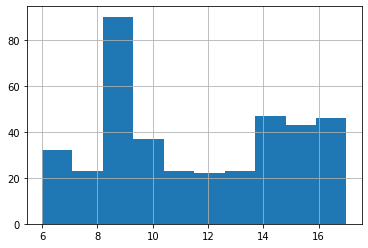

In [38]:
(drivers_4["AMBIENT_AIR_TEMP"][drivers_4["AMBIENT_AIR_TEMP"] >4]).hist()

<AxesSubplot:>

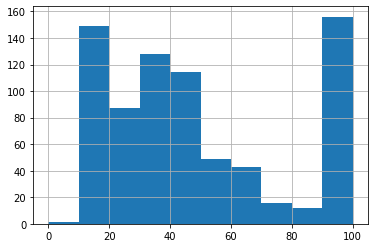

In [7]:
drivers_4["ENGINE_LOAD"].hist()

<AxesSubplot:>

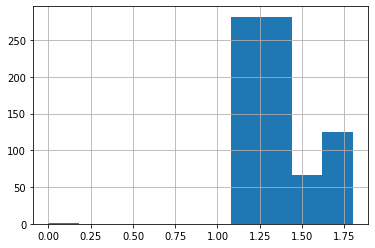

In [80]:
(drivers_4["MAF"] **(1/8)).hist()

<AxesSubplot:>

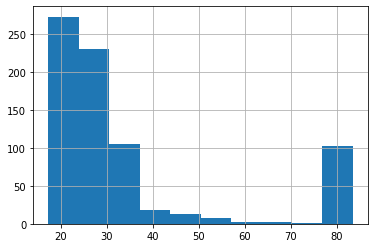

In [9]:
drivers_4["THROTTLE_POS"].hist()

<AxesSubplot:>

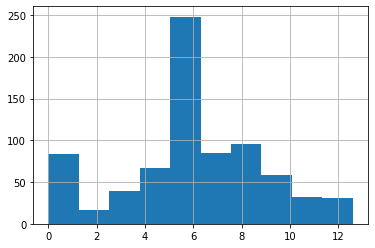

In [100]:
(drivers_4["SPEED"] ** .5).hist()

<AxesSubplot:>

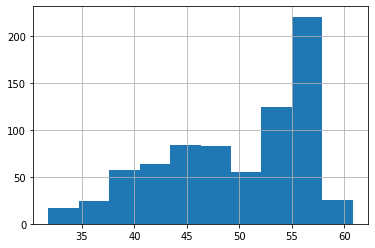

In [11]:
drivers_4["FUEL_LEVEL"].hist()

<AxesSubplot:>

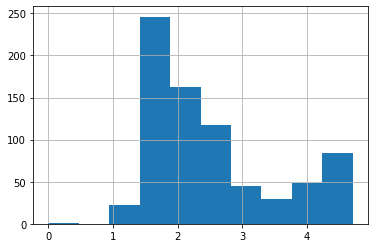

In [159]:
np.log(drivers_4["MAF"]  + 1).hist()

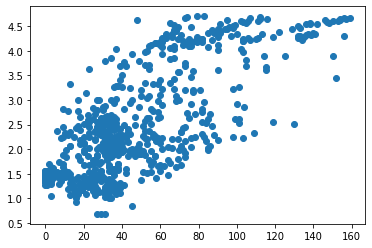

In [47]:
plt.scatter(x=drivers_4["SPEED"], y=np.log(drivers_4["MAF"]))

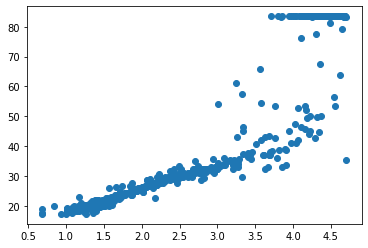

In [74]:
plt.scatter(x=np.log(drivers_4["MAF"]), y=drivers_4["THROTTLE_POS"])

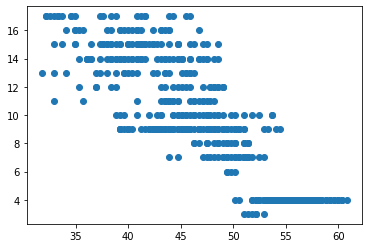

In [104]:
plt.scatter(y=drivers_4["AMBIENT_AIR_TEMP"], x=drivers_4["FUEL_LEVEL"])

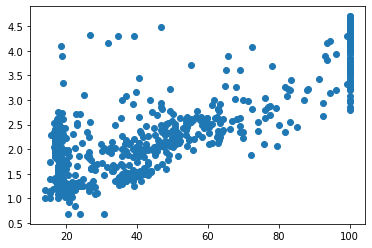

In [134]:
plt.scatter(x=drivers_4["ENGINE_LOAD"],y=np.log(drivers_4["MAF"]))

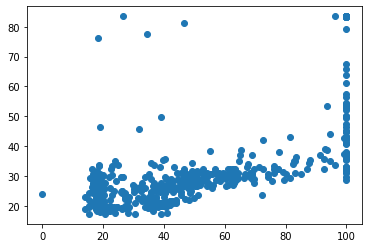

In [122]:
plt.scatter(x=drivers_4["ENGINE_LOAD"],y=drivers_4["THROTTLE_POS"])

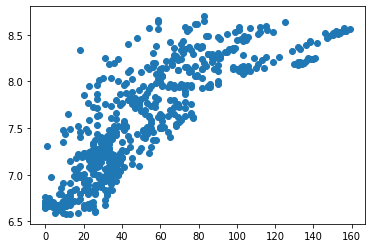

In [131]:
=1eplt.scatter(x=drivers_4["SPEED"],y=np.log(drivers_4["ENGINE_RPM"]))

In [138]:
drivers_4["LOG_ENGINE_RPM"] = np.log(drivers_4["ENGINE_RPM"] + 1e-6)
drivers_4["LOG_MAF"] = np.log(drivers_4["MAF"] + 1e-6)

drivers_19["LOG_ENGINE_RPM"] = np.log(drivers_19["ENGINE_RPM"] + 1e-6)
drivers_19["LOG_MAF"] = np.log(drivers_19["MAF"] +1e-6)

In [141]:
new_columns = [
    "ENGINE_COOLANT_TEMP", "AMBIENT_AIR_TEMP", "ENGINE_LOAD",
    "MAF", "THROTTLE_POS", "SPEED", "ENGINE_RPM", "FUEL_LEVEL",
]

In [142]:
new_drivers_4 = drivers_4[new_columns]
new_drivers_19 = drivers_19[new_columns]
new_drivers_14 = drivers_14[new_columns]

In [143]:
new_drivers_4[["LOG_ENGINE_RPM", "LOG_MAF"]] = drivers_4[["LOG_ENGINE_RPM", "LOG_MAF"]]
new_drivers_19[["LOG_ENGINE_RPM", "LOG_MAF"]] = drivers_19[["LOG_ENGINE_RPM", "LOG_MAF"]]


C:\Users\codin\AppData\Local\Temp/ipykernel_11412/3875681325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drivers_4[["LOG_ENGINE_RPM", "LOG_MAF"]] = drivers_4[["LOG_ENGINE_RPM", "LOG_MAF"]]
C:\Users\codin\AppData\Local\Temp/ipykernel_11412/3875681325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drivers_4[["LOG_ENGINE_RPM", "LOG_MAF"]] = drivers_4[["LOG_ENGINE_RPM", "LOG_MAF"]]
C:\Users\codin\AppData\Local\Temp/ipykernel_11412/3875681325.py:2: SettingWithCopyWarning: 
A value is trying 

In [145]:
new_drivers_4

,ENGINE_COOLANT_TEMP,AMBIENT_AIR_TEMP,ENGINE_LOAD,MAF,THROTTLE_POS,SPEED,ENGINE_RPM,FUEL_LEVEL,LOG_ENGINE_RPM,LOG_MAF
0,95.0,4.0,42.0,4.73,21.6,0.0,807,56.1,6.693324,1.553925
1,94.0,4.0,50.6,11.51,29.8,9.0,1559,56.1,7.351800,2.443216
2,93.0,4.0,41.2,10.29,29.0,10.0,1692,56.9,7.433667,2.331173
3,91.0,4.0,55.7,7.25,25.9,11.0,863,56.9,6.760415,1.981002
4,90.0,4.0,69.8,9.20,27.5,8.0,955,57.3,6.861711,2.219204
...,...,...,...,...,...,...,...,...,...,...
750,95.0,17.0,39.6,4.35,20.4,0.0,784,33.3,6.664409,1.470176
751,96.0,17.0,51.0,10.69,31.8,6.0,762,32.2,6.635947,2.369309
752,96.0,17.0,34.9,3.55,19.2,0.0,795,32.2,6.678342,1.266948
753,96.0,17.0,39.6,4.53,20.8,0.0,797,33.7,6.680855,1.510722


In [146]:
new_drivers_4.to_csv("new_drivers_4_clean.csv")
new_drivers_19.to_csv("new_drivers_19_clean.csv")
new_drivers_14.to_csv("new_drivers_14_clean.csv")